# Deterministic Rules — Results EDA

Evaluates the deterministic rule engine (`rules_alliance.py`) on the synthetic test set.
Decisions are **match / non_match / review**; every decision carries a `rule_id` traceable to `RULES.md`.

This notebook is **rules only** — the head-to-head with the GPT-2 model lives in `rules_vs_model.ipynb`.

In [1]:
import os, sys
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# locate repo root (works whether cwd is the notebook dir or the repo root)
REPO_ROOT = os.getcwd()
while not os.path.exists(os.path.join(REPO_ROOT, 'loo.py')) and os.path.dirname(REPO_ROOT) != REPO_ROOT:
    REPO_ROOT = os.path.dirname(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)
sys.path.insert(0, os.path.join(REPO_ROOT, 'deterministic_rules'))
import rules_alliance as R

pd.set_option('display.max_columns', None); pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

TEST_CSV = os.path.join(REPO_ROOT, 'data', 'synthetic', 'synthetic_test_v3.csv')

df = R.load_paired_csv(TEST_CSV)
scored = R.classify_df(df)
scored['label'] = scored['label'].astype(int)
n = len(scored)
print(f'{n} pairs  |  {int(scored.label.sum())} matches  /  {int((scored.label==0).sum())} non-matches')
scored[['PATID_A','PATID_B','label','case_type','rule_pred','rule_id','rule_reason']].head()

10000 pairs  |  2000 matches  /  8000 non-matches


,PATID_A,PATID_B,label,case_type,rule_pred,rule_id,rule_reason
0,S000098581,S000098582,0,NM-HARD-DOB+LASTNAME,non_match,R-DEMO-NAMEDIFF,no strong ID and names disagree
1,S000096321,S000096322,0,NM-HARD-DOB,non_match,R-DEMO-NAMEDIFF,no strong ID and names disagree
2,S000096671,S000096672,0,NM-HARD-ADDR,non_match,R-DEMO-NAMEDIFF,no strong ID and names disagree
3,S000091705,S000091706,0,NM-HARD-ADDR+DOB,non_match,R-DEMO-NAMEDIFF,no strong ID and names disagree
4,S000088389,S000088390,0,NM-HH-PARENT-CHILD,non_match,R-DEMO-NAMEDIFF,no strong ID and names disagree


## 1. Decision distribution & coverage

Decision distribution:
  match    :   1829  ( 18.3%)
  non_match:   7836  ( 78.4%)
  review   :    335  (  3.4%)

Auto-decision coverage (non-review): 96.7%


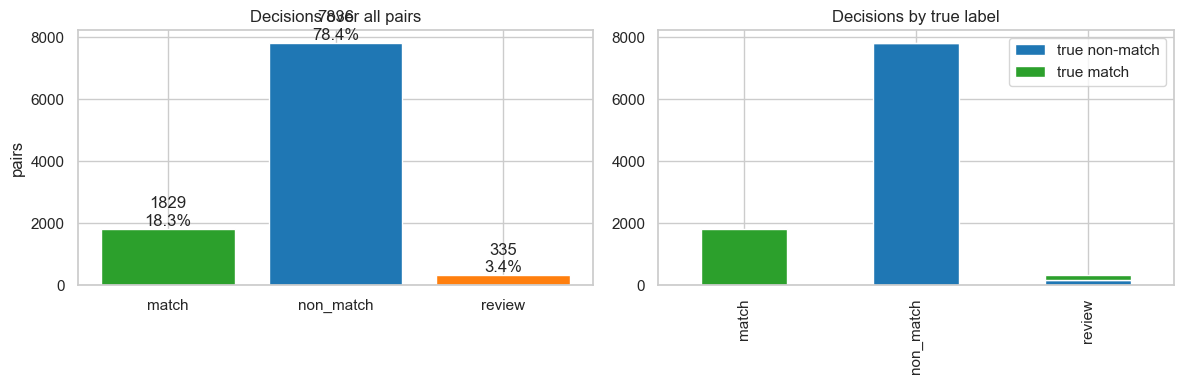

In [2]:
order = [R.MATCH, R.NON_MATCH, R.REVIEW]
dist = scored['rule_pred'].value_counts().reindex(order).fillna(0).astype(int)
coverage = (scored['rule_pred'] != R.REVIEW).mean()
print('Decision distribution:')
for k in order:
    print(f'  {k:9s}: {dist[k]:6d}  ({dist[k]/n:6.1%})')
print(f'\nAuto-decision coverage (non-review): {coverage:.1%}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
colors = {'match':'#2ca02c','non_match':'#1f77b4','review':'#ff7f0e'}
ax[0].bar(order, [dist[k] for k in order], color=[colors[k] for k in order])
ax[0].set_title('Decisions over all pairs'); ax[0].set_ylabel('pairs')
for i,k in enumerate(order):
    ax[0].text(i, dist[k], f'{dist[k]}\n{dist[k]/n:.1%}', ha='center', va='bottom')
# stacked by true label
ct = pd.crosstab(scored['rule_pred'], scored['label']).reindex(order).fillna(0)
ct.plot(kind='bar', stacked=True, ax=ax[1], color=['#1f77b4','#2ca02c'])
ax[1].set_title('Decisions by true label'); ax[1].set_xlabel(''); ax[1].legend(['true non-match','true match'])
plt.tight_layout(); plt.show()

## 2. Auto-decided subset — classification report & confusion matrix

Scored only on the pairs the rules decide (match/non_match). `review` pairs are excluded here — they are analyzed in §3.

Decided pairs: 9665 / 10000  (96.7% coverage)

               precision    recall  f1-score   support

non_match (0)     0.9999    0.9994    0.9996      7840
    match (1)     0.9973    0.9995    0.9984      1825

     accuracy                         0.9994      9665
    macro avg     0.9986    0.9994    0.9990      9665
 weighted avg     0.9994    0.9994    0.9994      9665



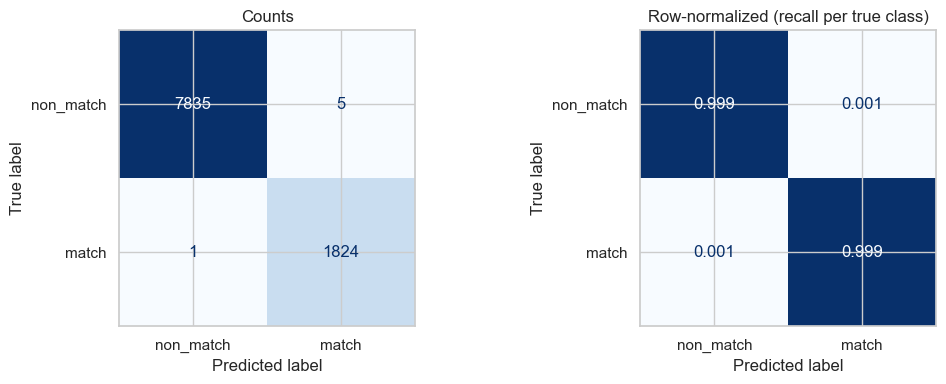

In [3]:
decided = scored[scored['rule_pred'] != R.REVIEW].copy()
decided['pred_bin'] = (decided['rule_pred'] == R.MATCH).astype(int)
y_true, y_pred = decided['label'], decided['pred_bin']

print(f'Decided pairs: {len(decided)} / {n}  ({len(decided)/n:.1%} coverage)\n')
print(classification_report(y_true, y_pred, target_names=['non_match (0)','match (1)'], digits=4))

cm = confusion_matrix(y_true, y_pred, labels=[0,1])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(cm, display_labels=['non_match','match']).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Counts')
ConfusionMatrixDisplay(cm/cm.sum(axis=1, keepdims=True), display_labels=['non_match','match']).plot(ax=ax[1], cmap='Blues', colorbar=False, values_format='.3f')
ax[1].set_title('Row-normalized (recall per true class)')
plt.tight_layout(); plt.show()

## 3. Review queue analysis

The review queue is the safety valve: pairs no deterministic rule can decide without more info (no strong ID + demographic look-alikes).

In [4]:
review = scored[scored['rule_pred'] == R.REVIEW]
total_pos = int((scored['label']==1).sum())
auto_tp = int(((decided['label']==1) & (decided['pred_bin']==1)).sum())
auto_fn = int(((decided['label']==1) & (decided['pred_bin']==0)).sum())
rv_pos = int((review['label']==1).sum()); rv_neg = int((review['label']==0).sum())

print(f'Review queue: {len(review)} pairs ({len(review)/n:.1%} of all)')
print(f'  true matches deferred    : {rv_pos} ({rv_pos/len(review):.1%} of queue)')
print(f'  true non-matches deferred: {rv_neg} ({rv_neg/len(review):.1%} of queue)')
print(f'\nPositive accounting (of {total_pos} true matches):')
print(f'  auto-matched              : {auto_tp} ({auto_tp/total_pos:.1%})')
print(f'  sent to review            : {rv_pos} ({rv_pos/total_pos:.1%})')
print(f'  auto-non-matched (missed) : {auto_fn} ({auto_fn/total_pos:.1%})')

# which rules drive the review queue, and the true-label mix per rule
rv_tab = review.groupby('rule_id')['label'].agg(['count','sum'])
rv_tab.columns = ['n_review','n_true_match']; rv_tab['n_true_nonmatch'] = rv_tab['n_review']-rv_tab['n_true_match']
display(rv_tab.sort_values('n_review', ascending=False))

Review queue: 335 pairs (3.4% of all)
  true matches deferred    : 175 (52.2% of queue)
  true non-matches deferred: 160 (47.8% of queue)

Positive accounting (of 2000 true matches):
  auto-matched              : 1824 (91.2%)
  sent to review            : 175 (8.8%)
  auto-non-matched (missed) : 1 (0.1%)


,n_review,n_true_match,n_true_nonmatch
rule_id,,,
R-DEMO-AMBIG,263,154,109
R-L4-REVIEW,71,21,50
R-SSN-L4-CONFLICT,1,0,1


## 4. Per-case_type decision breakdown (design validation)

Confirms each scenario is handled as designed (e.g. `M-SSN-*`→match, `NM-SSN-03/04`→non_match, `POL-AMBIG-03` & twins→review).

rule_pred,match,non_match,review,label
case_type,,,,
NM-HARD-DOB+LASTNAME+PHONE,4,114,6,0
NM-COMMON-06,1,45,47,0
NM-HARD-DOB,0,740,1,0
NM-HARD-LASTNAME,0,727,0,0
NM-HARD-ADDR,0,708,0,0
NM-HARD-PHONE,0,679,0,0
NM-HARD-LAST4,0,231,1,0
NM-HARD-DOB+PHONE,0,225,0,0
NM-HARD-ADDR+DOB,0,224,0,0


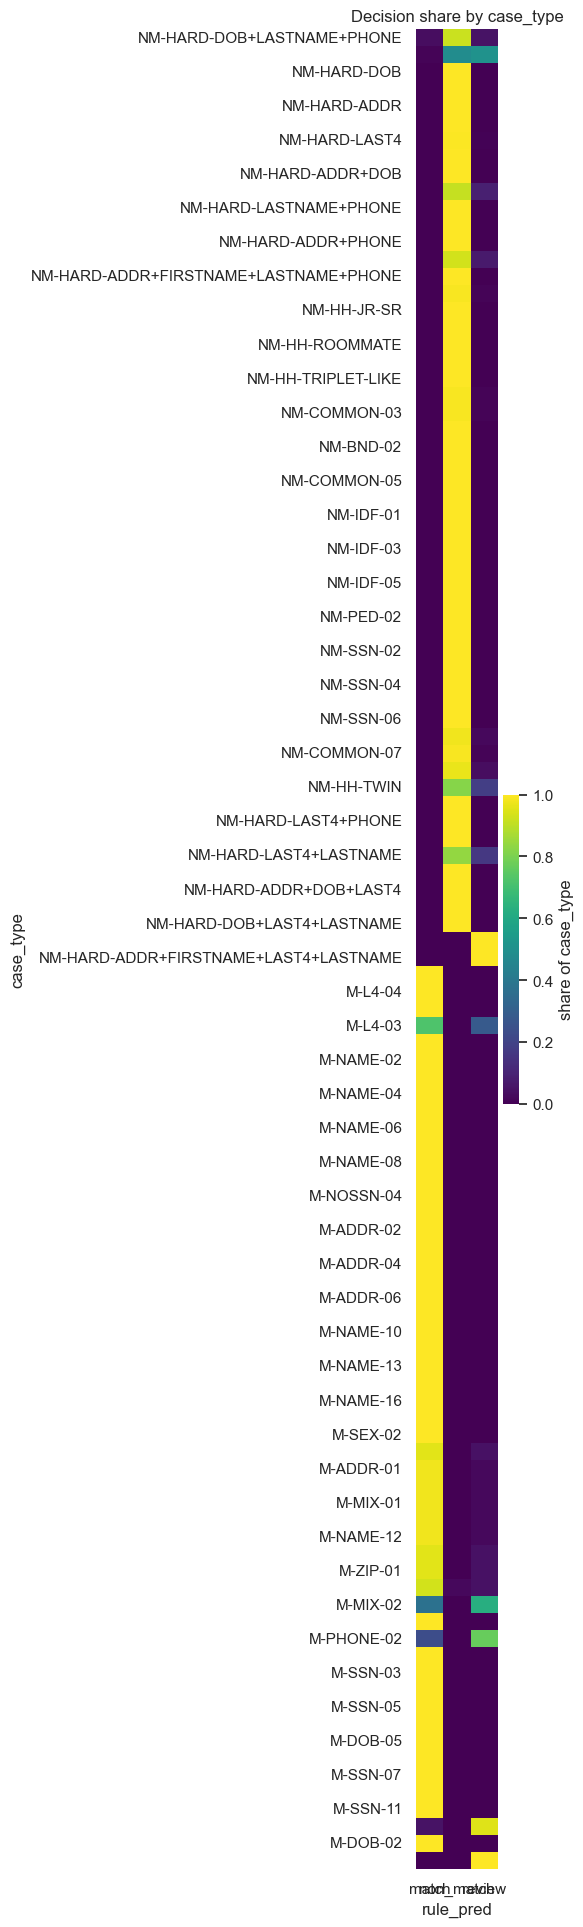

In [5]:
tab = (scored.groupby(['case_type','rule_pred']).size().unstack(fill_value=0)
       .reindex(columns=order, fill_value=0))
tab['label'] = scored.groupby('case_type')['label'].first()
tab = tab.sort_values(['label']+order, ascending=[True]+[False]*3)
with pd.option_context('display.max_rows', None):
    display(tab)

# heatmap: row-normalized decision share per case_type
share = tab[order].div(tab[order].sum(axis=1), axis=0)
plt.figure(figsize=(6, max(8, len(share)*0.18)))
sns.heatmap(share, annot=False, cmap='viridis', cbar_kws={'label':'share of case_type'})
plt.title('Decision share by case_type'); plt.tight_layout(); plt.show()

## 5. Rule firing counts & per-rule accuracy

In [6]:
decided_map = {R.MATCH:1, R.NON_MATCH:0}
rec = []
for rid, grp in scored.groupby('rule_id'):
    dec = grp['rule_pred'].iloc[0]
    if dec in decided_map:
        correct = int((grp['label'] == decided_map[dec]).sum())
        acc = correct/len(grp)
    else:
        correct, acc = np.nan, np.nan
    rec.append((rid, dec, len(grp), correct, acc))
rule_tab = pd.DataFrame(rec, columns=['rule_id','decision','n','n_correct','accuracy']).sort_values('n', ascending=False)
display(rule_tab)

,rule_id,decision,n,n_correct,accuracy
3,R-DEMO-NAMEDIFF,non_match,5290,5289.0,0.999811
2,R-DEMO-MATCH,match,1440,1435.0,0.996528
1,R-DEMO-DOBCONTRA,non_match,1076,1076.0,1.000000
4,R-L4-COLLISION,non_match,762,762.0,1.000000
10,R-SSN-L4-CONFLICT,non_match,294,294.0,1.000000
6,R-L4-MATCH,match,279,279.0,1.000000
0,R-DEMO-AMBIG,review,263,NaN,NaN
8,R-SSN-COLLISION,non_match,186,186.0,1.000000
9,R-SSN-CONFLICT,non_match,151,151.0,1.000000
12,R-SSN-MATCH,match,100,100.0,1.000000


## 6. Example cases — good, bad, and review

Concrete pairs so you can eyeball *why* each decision was made.

In [7]:
SHOW = ['first_name','middle_name','last_name','suffix','dob','ssn','ssn4','address','zip','phone','email']
def _v(x):
    return '' if (x is None or (isinstance(x,float) and pd.isna(x)) or str(x).lower() in ('nan','none','<na>')) else str(x)
def show_examples(sub, k=4, title=''):
    print('='*92); print(f'{title}   (n={len(sub)})'); print('='*92)
    for _, row in sub.head(k).iterrows():
        print(f"[{row.case_type}] label={row.label}  ->  {row.rule_pred} ({row.rule_id}): {row.rule_reason}")
        for f in SHOW:
            l, r = _v(row.get(f+'_l')), _v(row.get(f+'_r'))
            if l or r:
                flag = '' if l == r else '   <-- differs'
                print(f'    {f:11s}: {l:30s} | {r:30s}{flag}')
        print()

rng = np.random.RandomState(0)
def samp(mask, k=4):
    idx = scored[mask].index
    return scored.loc[rng.permutation(idx)[:k]] if len(idx) else scored.iloc[0:0]

In [8]:
# GOOD: correct auto-matches
show_examples(samp((scored.rule_pred==R.MATCH) & (scored.label==1)), title='GOOD — correct auto-MATCH')
# GOOD: correct auto-non-matches that are SSN/last-4 collisions (hardest negatives)
show_examples(samp((scored.rule_pred==R.NON_MATCH) & (scored.label==0) & (scored.rule_id.str.contains('COLLISION'))),
              title='GOOD — correct auto-NON_MATCH (SSN/last-4 collision rejected)')

GOOD — correct auto-MATCH   (n=4)
[M-SSN-08] label=1  ->  match (R-SSN-MATCH): full SSN equal; name=exact_tokens, dob=near
    first_name : DIANA                          | DIANA                         
    middle_name: K                              | K                             
    last_name  : AGUILAR                        | AGUILAR                       
    dob        : 2022-12-04                     | 2022-12-03                       <-- differs
    ssn        : 357027465                      | 357027465                     
    ssn4       : 7465                           | 7465                          
    address    : 4042 LAFLIN AVE                | 4042 LAFLIN AVE               
    zip        : 60653                          | 60653                         
    phone      : 3317196284 4647327853          | 3317196284 4647327853         

[M-NAME-05] label=1  ->  match (R-DEMO-MATCH): name+dob agree and a shared phone/email links the records
    first_name : THI HUONG  

In [9]:
# BAD: false matches (auto-match but truly non-match)
show_examples(scored[(scored.rule_pred==R.MATCH) & (scored.label==0)], k=10, title='BAD — FALSE MATCH (pred match, truth non-match)')
# BAD: missed matches (auto-non-match but truly a match)
show_examples(scored[(scored.rule_pred==R.NON_MATCH) & (scored.label==1)], k=10, title='BAD — MISSED MATCH (pred non_match, truth match)')

BAD — FALSE MATCH (pred match, truth non-match)   (n=5)
[NM-HARD-DOB+LASTNAME+PHONE] label=0  ->  match (R-DEMO-MATCH): name+dob agree and a shared phone/email links the records
    first_name : SANDRA                         | SSANDRA                          <-- differs
    last_name  : MARQUEZ                        | MARQUEZ                       
    dob        : 1980-06-03                     | 1980-06-03                    
    ssn        :                                | 040429066                        <-- differs
    ssn4       :                                | 9066                             <-- differs
    address    : 18 HURON AVE                   | 6287 ROOSEVELT ST                <-- differs
    zip        : 21215                          | 60707                            <-- differs
    phone      : 3019050008 4109655900 4436480440 | 3019050008 7083966418 8156666281   <-- differs

[NM-HARD-DOB+LASTNAME+PHONE] label=0  ->  match (R-DEMO-MATCH): name+dob agree and a 

In [10]:
# REVIEW: true matches we deferred (no strong ID)
show_examples(samp((scored.rule_pred==R.REVIEW) & (scored.label==1)), title='REVIEW — true MATCH deferred (demographic-only, no strong ID)')
# REVIEW: true non-matches we deferred (look-alike households / common names)
show_examples(samp((scored.rule_pred==R.REVIEW) & (scored.label==0)), title='REVIEW — true NON_MATCH deferred (look-alike)')

REVIEW — true MATCH deferred (demographic-only, no strong ID)   (n=4)
[POL-AMBIG-03] label=1  ->  review (R-DEMO-AMBIG): name+dob agree but contact info differs and nothing links them (mover vs namesake)
    first_name : JENNIFER                       | JENNIFER                      
    last_name  : ESPINOZA                       | ESPINOZA                      
    dob        : 1972-12-03                     | 1972-12-03                    
    address    : 13874 HURON DR                 | 13874 HURON DR                
    zip        : 60644                          | 60644                         
    phone      : 3127620258 3312306119 8479717390 | 6305699878 8157522726 8722084951   <-- differs

[M-L4-03] label=1  ->  review (R-L4-REVIEW): last-4 equal; name=exact_tokens, dob=disagree
    first_name : JESSICA VERONICA               | JESSICA VERONICA              
    last_name  : RUIZ                           | RUIZ                          
    dob        : 1971-11-19           